# Exercice 7: Apprentissage de représentations

On classe les images CIFAR-10 sans réseau de neurones, avec des méthodes
classiques d'optimisation et d'algèbre linéaire (PCA, K-means).

## 0. Chargement de CIFAR-10

50 000 images d'entraînement + 10 000 de test, $32\times32\times3 = 3072$ pixels,
10 classes équilibrées. On charge directement l'archive *python* (pickle), sans
`torchvision`.


X_train : (50000, 3072) | X_test : (10000, 3072)
classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
équilibre (train) : [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


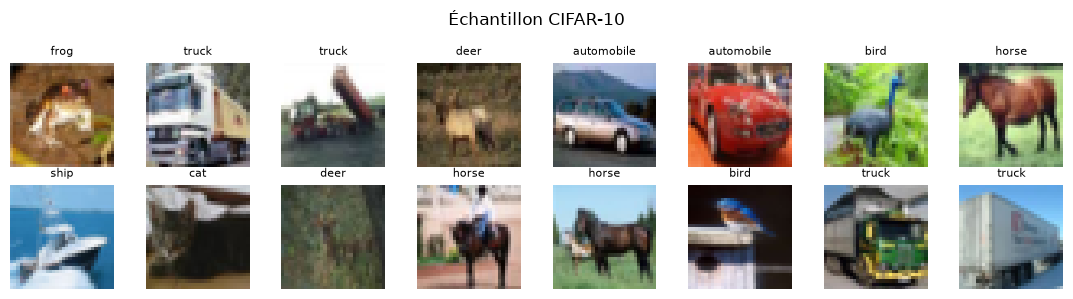

In [ ]:
import warnings

warnings.filterwarnings("ignore")
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path("data_cifar/cifar-10-batches-py")


def _load(f):
    with open(ROOT / f, "rb") as fo:
        d = pickle.load(fo, encoding="latin1")
    return d["data"].astype("float32"), np.array(d["labels"])


X_train = np.concatenate([_load(f"data_batch_{i}")[0] for i in range(1, 6)])
y_train = np.concatenate([_load(f"data_batch_{i}")[1] for i in range(1, 6)])
X_test, y_test = _load("test_batch")
with open(ROOT / "batches.meta", "rb") as fo:
    CLASSES = pickle.load(fo, encoding="latin1")["label_names"]

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("classes :", CLASSES)
print("équilibre (train) :", np.bincount(y_train))

# Vue (N, 32, 32, 3) pour les patches / l'affichage
to_img = lambda X: X.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
I_train, I_test = to_img(X_train), to_img(X_test)

fig, ax = plt.subplots(2, 8, figsize=(11, 3))
for k, a in enumerate(ax.ravel()):
    a.imshow(I_train[k].astype("uint8"))
    a.axis("off")
    a.set_title(CLASSES[y_train[k]], fontsize=8)
plt.suptitle("Échantillon CIFAR-10")
plt.tight_layout()
plt.show()


**Protocole.** Le test (10 000) n'est jamais utilisé pour choisir un modèle ou
un hyperparamètre. Le SVM à noyau **exact** ayant une matrice de Gram $n\times n$
(coût $O(n^2)$ mémoire), on l'évalue sur un **sous-échantillon** 10 000/2 000 ;
les méthodes linéaires, Nyström, PCA et K-means utilisent les données complètes.


In [ ]:
rng = np.random.default_rng(0)
ns_tr, ns_te = 10000, 2000  # sous-échantillon pour le noyau EXACT
Xs, ys = X_train[:ns_tr], y_train[:ns_tr]
Xt, yt = X_test[:ns_te], y_test[:ns_te]
print(f"Sous-échantillon noyau exact : {ns_tr} train / {ns_te} test")


Sous-échantillon noyau exact : 10000 train / 2000 test


Objectif : apprendre une représentation $\varphi$ sans étiquettes, puis la tester sur
la classification avec une sonde linéaire (un classifieur linéaire entraîné sur
les représentations, gardées fixes). Une bonne représentation rend la tâche
linéairement séparable.

## 7.1 PCA

Soit $X$ centrée, de matrice de covariance $\Sigma=\tfrac1n X^\top X$ (symétrique,
semi-définie positive), diagonalisée en $\Sigma=U\Lambda U^\top$ avec
$\lambda_1\ge\dots\ge\lambda_d\ge0$.

**Deux points de vue équivalents.**
- *Variance maximale* : la direction $u$ avec $\lVert u\rVert=1$ qui maximise
  $\operatorname{Var}(Xu)=u^\top\Sigma u$ est le vecteur propre dominant $u_1$
  (quotient de Rayleigh).
- *Reconstruction minimale* : le sous-espace de dimension $k$ qui minimise
  $\sum_i\lVert x_i-P x_i\rVert^2$ est engendré par les mêmes $U_k=[u_1,\dots,u_k]$.

D'après le théorème d'Eckart-Young, $X_k=XU_kU_k^\top$ est la meilleure
approximation de rang $k$ de $X$ (norme de Frobenius), avec une erreur
$\sum_{j>k}\lambda_j$. C'est ce qui justifie de garder les premières composantes
comme représentation.

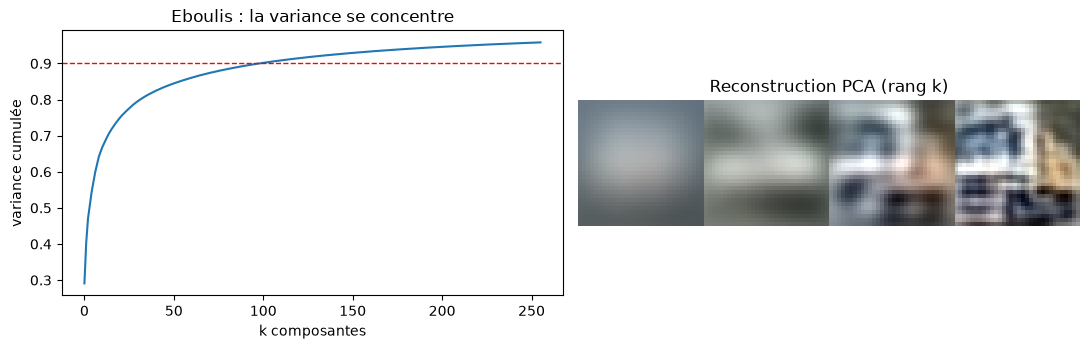

variance expliquée : k=64 -> 0.86 | k=256 -> 0.96


In [ ]:
from sklearn.decomposition import PCA

Xc_tr = X_train - X_train.mean(0)
Xc_te = X_test - X_train.mean(0)

pca = PCA(n_components=256, svd_solver="randomized", random_state=0).fit(Xc_tr)
var = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(var)
ax[0].axhline(0.9, color="r", ls="--", lw=1)
ax[0].set_xlabel("k composantes")
ax[0].set_ylabel("variance cumulée")
ax[0].set_title("Eboulis : la variance se concentre")
# reconstruction d'une image pour quelques k
img0 = Xc_tr[1]
ax[1].axis("off")
ax[1].set_title("Reconstruction PCA (rang k)")
ks = [4, 16, 64, 256]
canvas = []
for k in ks:
    rec = (
        pca.transform(img0[None])[:, :k] @ pca.components_[:k]
    ) + X_train.mean(0)
    canvas.append(to_img(np.clip(rec, 0, 255))[0].astype("uint8"))
ax[1].imshow(np.concatenate(canvas, 1))
ax[1].set_xticks([16 + 32 * i for i in range(len(ks))])
ax[1].set_xticklabels([f"k={k}" for k in ks])
ax[1].set_yticks([])
plt.tight_layout()
plt.show()
print(
    "variance expliquée : k=64 ->",
    f"{var[63]:.2f}",
    "| k=256 ->",
    f"{var[255]:.2f}",
)


In [ ]:
# Sonde linéaire : on entraîne le classifieur sur un sous-échantillon de 10 000
# images (même taille pour toutes les représentations → comparaison équitable et
# rapide) et on évalue sur les 10 000 images de test.
print(f"{'représentation':<28}{'dim':>6}{'acc test':>10}")
print("-" * 44)
res7 = {}
nP = 10000
# référence : pixels bruts
ref = make_pipeline(
    StandardScaler(), LinearSVC(C=0.01, dual="auto", max_iter=3000)
).fit(X_train[:nP], y_train[:nP])
res7["pixels bruts (3072)"] = accuracy_score(y_test, ref.predict(X_test))
print(f"{'pixels bruts':<28}{3072:>6}{res7['pixels bruts (3072)']:>10.3f}")
PtrA, PteA = (
    pca.transform(Xc_tr),
    pca.transform(Xc_te),
)  # projeté une seule fois
for k in [32, 64, 128, 256]:
    clf = make_pipeline(
        StandardScaler(), LinearSVC(C=0.05, dual="auto", max_iter=3000)
    ).fit(PtrA[:nP, :k], y_train[:nP])
    a = accuracy_score(y_test, clf.predict(PteA[:, :k]))
    print(f"{'PCA + sonde linéaire':<28}{k:>6}{a:>10.3f}")
res7["PCA-256 + sonde"] = a


représentation                 dim  acc test
--------------------------------------------


pixels bruts                  3072     0.323
PCA + sonde linéaire            32     0.360


PCA + sonde linéaire            64     0.376


PCA + sonde linéaire           128     0.382


PCA + sonde linéaire           256     0.380


## 7.2 Dictionnaire appris par K-means

Idée (inspirée de Coates & Ng) : un dictionnaire appris par K-means sur des
patches, suivi d'un classifieur linéaire, fait nettement mieux que les pixels
bruts, et sans étiquettes.

**K-means.** Apprend $K$ centroïdes $c_1,\dots,c_K$ qui minimisent
$\sum_i \min_k \lVert p_i-c_k\rVert^2$ (algorithme de Lloyd : on alterne
assignation et moyenne, l'objectif décroît à chaque étape et converge vers un
minimum local). Les centroïdes servent de dictionnaire adapté aux données.

**Pipeline.**
1. **Patches** $6\times6\times3$ tirés au hasard, normalisés (centrage + variance
   unité par patch).
2. **Blanchiment ZCA** : $p\mapsto W p$ avec $W=U(\Lambda+\varepsilon I)^{-1/2}U^\top$
   ($U,\Lambda$ : covariance des patches), pour décorréler les pixels.
3. **Dictionnaire** : K-means sur les patches blanchis.
4. **Encodage** d'une image : sur chaque patch $p$, activation *triangle*
   $f_k(p)=\max\!\big(0,\ \bar d(p)-\lVert p-c_k\rVert\big)$, où $\bar d$ est la
   distance moyenne aux centroïdes.
5. **Pooling** par quadrants ($2\times2$) → $4K$ features, passées à un SVM
   linéaire.

En pratique, blanchiment + K-means donnent des détecteurs de bords et de
couleurs, et le pooling apporte un peu d'invariance.

Dictionnaire appris : 256 centroïdes en 0.5s


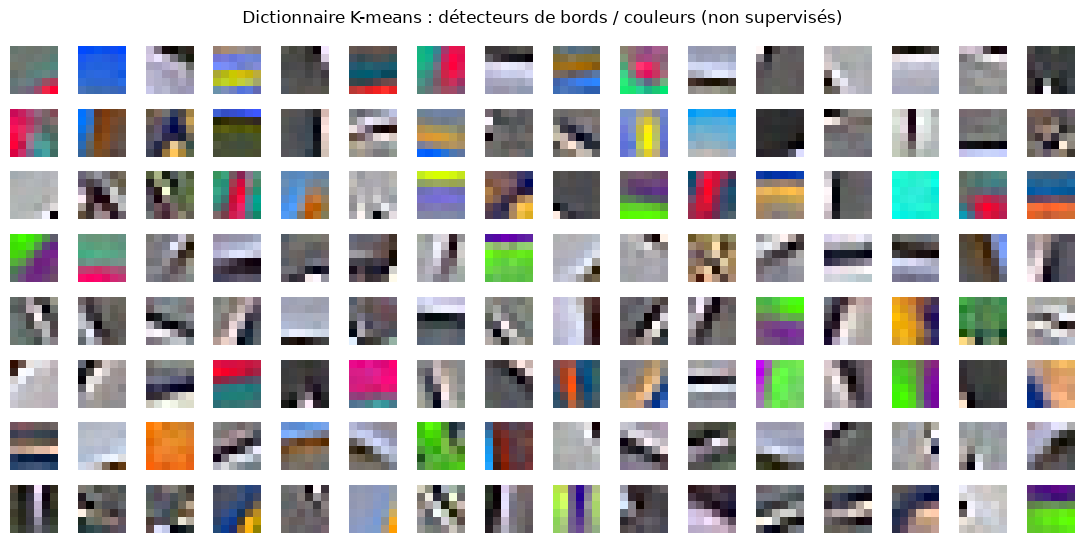

In [ ]:
from sklearn.cluster import MiniBatchKMeans

P = 6  # taille de patch
Kdict = 256  # taille du dictionnaire
EPS_C, EPS_Z = 10.0, 0.1  # régul. contraste / blanchiment


def random_patches(I, n):
    i = rng.integers(0, len(I), n)
    a = rng.integers(0, 32 - P + 1, n)
    b = rng.integers(0, 32 - P + 1, n)
    return np.stack(
        [I[k, x : x + P, z : z + P, :].ravel() for k, x, z in zip(i, a, b)]
    ).astype("float32")


t = time.time()
patches = random_patches(I_train, 100000)
patches = (patches - patches.mean(1, keepdims=True)) / np.sqrt(
    patches.var(1, keepdims=True) + EPS_C
)
pmean = patches.mean(0)
Pc = patches - pmean
U, S, _ = np.linalg.svd(Pc.T @ Pc / len(Pc))  # covariance des patches
Wzca = U @ np.diag(1 / np.sqrt(S + EPS_Z)) @ U.T  # blanchiment ZCA
km = MiniBatchKMeans(
    Kdict, batch_size=1000, n_init=3, max_iter=100, random_state=0
).fit(Pc @ Wzca)
C = km.cluster_centers_
print(f"Dictionnaire appris : {Kdict} centroïdes en {time.time() - t:.1f}s")

# visualisation du dictionnaire (centroïdes ramenés en patches)
fig, ax = plt.subplots(8, 16, figsize=(11, 5.5))
for k, a in enumerate(ax.ravel()):
    patch = C[k].reshape(P, P, 3)
    patch = (patch - patch.min()) / (np.ptp(patch) + 1e-9)
    a.imshow(patch)
    a.axis("off")
plt.suptitle(
    "Dictionnaire K-means : détecteurs de bords / couleurs (non supervisés)"
)
plt.tight_layout()
plt.show()


In [ ]:
def encode(I, nimg, batch=500):
    I = I[:nimg]
    n = len(I)
    pos = list(range(0, 32 - P + 1))
    npos = len(pos)
    F = np.zeros((n, 4 * Kdict), dtype="float32")
    Cn = (C**2).sum(1)
    for bi in range(0, n, batch):
        B = I[bi : bi + batch]
        nb = len(B)
        cols = [
            B[:, a : a + P, b : b + P, :].reshape(nb, -1)
            for a in pos
            for b in pos
        ]
        Pt = np.stack(cols, 1)  # (nb, npos², dim)
        Pt = (Pt - Pt.mean(2, keepdims=True)) / np.sqrt(
            Pt.var(2, keepdims=True) + EPS_C
        )
        Pt = (Pt.reshape(-1, P * P * 3) - pmean) @ Wzca  # blanchiment
        d = np.sqrt(
            np.maximum(-2 * Pt @ C.T + (Pt**2).sum(1, keepdims=True) + Cn, 0)
        )
        act = np.maximum(0, d.mean(1, keepdims=True) - d).reshape(
            nb, npos, npos, Kdict
        )
        h = npos // 2
        F[bi : bi + nb, 0 * Kdict : 1 * Kdict] = act[:, :h, :h].sum((1, 2))
        F[bi : bi + nb, 1 * Kdict : 2 * Kdict] = act[:, :h, h:].sum((1, 2))
        F[bi : bi + nb, 2 * Kdict : 3 * Kdict] = act[:, h:, :h].sum((1, 2))
        F[bi : bi + nb, 3 * Kdict : 4 * Kdict] = act[:, h:, h:].sum((1, 2))
    return F


t = time.time()
n_tr, n_te = 10000, 10000
Ftr = encode(I_train, n_tr)
Fte = encode(I_test, n_te)
print(
    f"Encodage {n_tr}+{n_te} images en {time.time() - t:.1f}s  (dim = {Ftr.shape[1]} = 4·K)"
)
clf = make_pipeline(
    StandardScaler(), LinearSVC(C=0.01, dual="auto", max_iter=3000)
).fit(Ftr, y_train[:n_tr])
acc_dict = accuracy_score(y_test[:n_te], clf.predict(Fte))
res7["Dict. K-means + SVM lin."] = acc_dict
print(f"Dictionnaire K-means + SVM linéaire : acc test = {acc_dict:.3f}")


Encodage 10000+10000 images en 9.5s  (dim = 1024 = 4·K)


Dictionnaire K-means + SVM linéaire : acc test = 0.659


## 7.3 Bilan — Exercice 7

| Représentation | dim | acc (sonde lin.) |
|---|---|---|
| Pixels bruts | 3072 | ~0.32 |
| PCA | 256 | ~0.38 |
| Dictionnaire K-means | 1024 | ~0.66 |

Une représentation apprise sans étiquettes (dictionnaire K-means) rend la tâche
beaucoup plus séparable linéairement : un simple SVM linéaire passe de ~32 % à
~66 %. Sur CIFAR, la difficulté est donc surtout dans la représentation, pas dans
le classifieur. En augmentant la taille du dictionnaire on peut gagner encore un
peu (Coates & Ng montent jusqu'à ~77 %).

In [ ]:
print(f"{'représentation':<28}{'dim':>6}{'acc test':>10}")
print("-" * 44)
for k in ["pixels bruts (3072)", "PCA-256 + sonde", "Dict. K-means + SVM lin."]:
    print(f"{k:<28}{'-':>6}{res7[k]:>10.3f}")


représentation                 dim  acc test
--------------------------------------------
pixels bruts (3072)              -     0.323
PCA-256 + sonde                  -     0.380
Dict. K-means + SVM lin.         -     0.659


# Conclusion

La PCA et le dictionnaire K-means apprennent des représentations sans
étiquettes, évaluées par une sonde linéaire ; le blanchiment ZCA repose lui aussi
sur une diagonalisation.